<a href="https://colab.research.google.com/github/jupiterbouncer/Sankofa-Symptom-Checker/blob/feature%2Finference-pipeline/notebooks/05_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import joblib
import os
from google.colab import drive, files

print(os.getcwd())
drive.mount("/content/drive")

/content
Mounted at /content/drive


## LOADING MODEL, ENCODER AND TEST DATA

In [2]:
rf = joblib.load('/content/drive/MyDrive/SE-dataset/random_forest.pkl')
le = joblib.load('/content/drive/MyDrive/SE-dataset/label_encoder.pkl')

The trained Random Forest model and fitted LabelEncoder are loaded from saved joblib files. This notebook evaluates the already-trained model instead of retraining it.

In [3]:
# reloading test split
df = pd.read_csv(
    "/content/drive/MyDrive/SE-dataset/cleaned_diseases_symptoms.csv"
)

MIN_SAMPLES = 20

counts = df['diseases'].value_counts()
df = df[df['diseases'].isin(counts[counts >= MIN_SAMPLES].index)].copy()
X = df.drop(columns = ['diseases'])
y = le.transform(df['diseases'])

from sklearn.model_selection import train_test_split
_, X_temp, _, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
_, X_test, _, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

y_pred = rf.predict(X_test)

The cleaned dataset is loaded and filtered to keep diseases with at least 20 examples, matching the training notebook. It is then separated into X, containing the symptom feature columns, and y, containing disease labels transformed with the saved LabelEncoder.

The same two-step stratified split is recreated using random_state = 42 so the evaluation uses the same held-out 20% test set design as training.
The stratify argument helps preserve disease-class proportions so lower-frequency classes are still represented where possible.

The loaded model then predicts disease classes for the test feature rows, allowing its performance to be measured against the true labels.

## OVERALL METRICS

In [4]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Macro-F1:  {f1_score(y_test, y_pred, average='macro', zero_division=0)}")
print(f"Weighted-F1: {f1_score(y_test, y_pred, average='weighted', zero_division=0)}")

Accuracy: 0.836935855098569
Macro-F1:  0.8083731847376174
Weighted-F1: 0.8431118836529935


The model reaches 83.69% accuracy, 80.84% macro-F1, and 84.31% weighted-F1 on the test set. The weighted-F1 score is slightly higher than macro-F1, which suggests the model performs better on more common classes than on lower-support classes. Because macro-F1 gives each disease equal weight, it is an important metric for judging performance across the full set of diseases.

## PER-CLASS REPORT (by F1)

In [5]:
report = classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report).T.iloc[:-3]  # drop avg rows
report_df = report_df.sort_values('f1-score', ascending=False)

print("\nTop 10 best predicted diseases:")
print(report_df.head(10)[['precision', 'recall', 'f1-score', 'support']])

print("\nBottom 10 worst predicted diseases:")
print(report_df.tail(10)[['precision', 'recall', 'f1-score', 'support']])


Top 10 best predicted diseases:
                                precision  recall  f1-score  support
thrombocytopenia                      1.0     1.0       1.0     13.0
toxic multinodular goiter             1.0     1.0       1.0      4.0
sickle cell anemia                    1.0     1.0       1.0     27.0
scoliosis                             1.0     1.0       1.0     17.0
osteomyelitis                         1.0     1.0       1.0     15.0
menopause                             1.0     1.0       1.0      5.0
cellulitis or abscess of mouth        1.0     1.0       1.0     12.0
cerebral palsy                        1.0     1.0       1.0      9.0
lymphoma                              1.0     1.0       1.0      8.0
fibroadenoma                          1.0     1.0       1.0      8.0

Bottom 10 worst predicted diseases:
                                        precision    recall  f1-score  support
seborrheic keratosis                     0.447368  0.283333  0.346939     60.0
retinopathy d

classification_report is used to generate a per-disease performance breakdown with precision, recall, F1-score, and support for each disease class. The report is sorted by F1-score to show the ten best and ten weakest disease-level results. Some high-performing classes reach perfect scores on the held-out examples, while the weakest classes show low F1-scores and often have low support, indicating that rare or easily confused diseases remain a limitation.

## F1 SCORE DISTRIBUTION

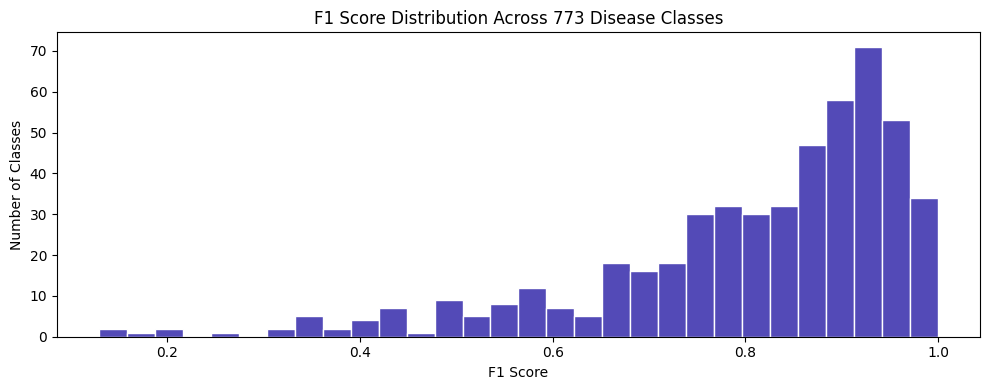

In [6]:
plt.figure(figsize=(10, 4))
plt.hist(report_df['f1-score'], bins=30, color='#534ab7', edgecolor='white')
plt.title('F1 Score Distribution Across 773 Disease Classes')
plt.xlabel('F1 Score')
plt.ylabel('Number of Classes')
plt.tight_layout()
plt.show()

The histogram shows the distribution of F1-scores across disease classes. The x-axis represents F1-score and the y-axis represents the number of diseases in each score range. Most classes perform reasonably well, but the lower tail shows that some diseases still receive weak F1-scores. This supports the audit concern that class imbalance and low-support classes can affect reliability even when overall metrics are strong.

## CONFUSION MATRIX (top 20 diseases only)

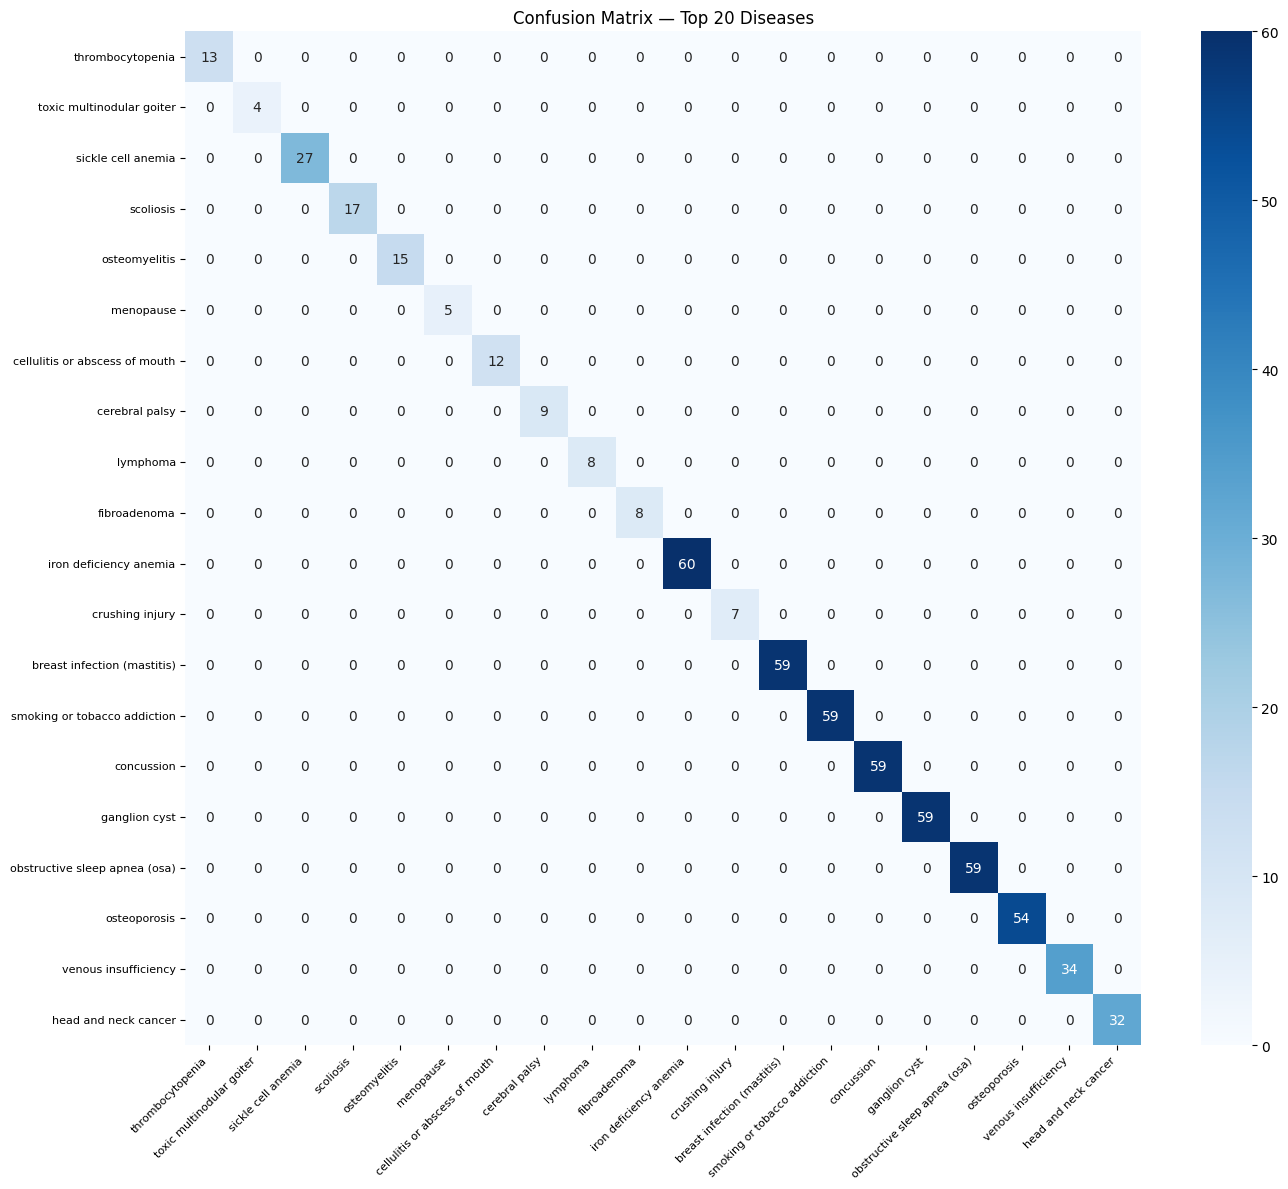

In [7]:
top20 = report_df.head(20).index.tolist()
top20_idx = [le.transform([d])[0] for d in top20]

mask = np.isin(y_test, top20_idx)
y_test_top = y_test[mask]
y_pred_top = y_pred[mask]

cm = confusion_matrix(y_test_top, y_pred_top, labels=top20_idx)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top20, yticklabels=top20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.title('Confusion Matrix — Top 20 Diseases')
plt.tight_layout()
plt.show()

A confusion matrix is drawn for the 20 best-performing diseases from the per-class report. Rows represent true disease labels and columns represent predicted labels. Strong diagonal values with few or no off-diagonal values indicate that the model distinguishes these selected high-performing classes well; however, this view does not represent performance for weaker or lower-support diseases.

## FEATURE IMPORTANCE (top 20 symptoms)

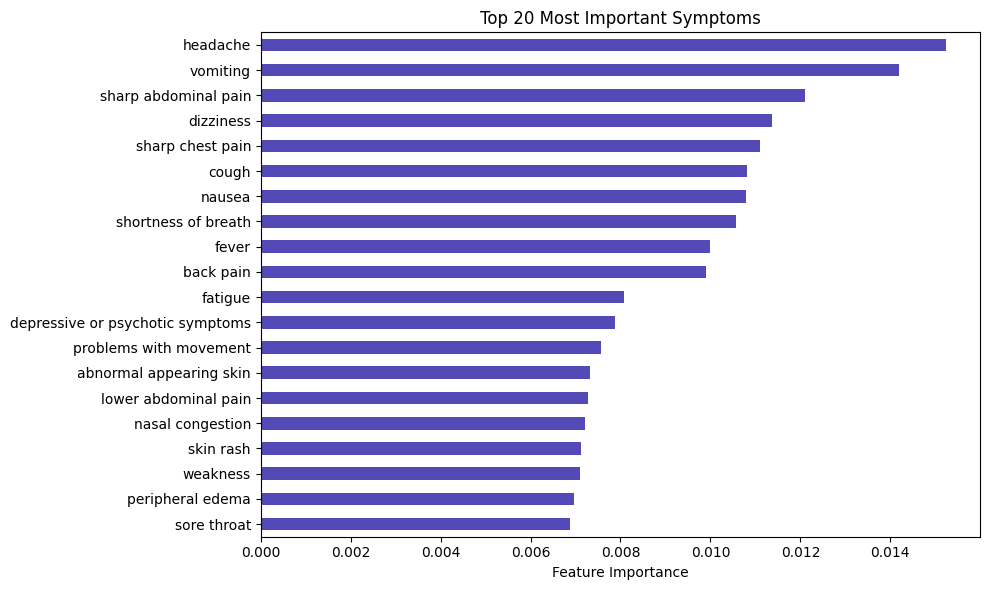

In [8]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_symptoms = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_symptoms.plot(kind='barh', color='#534ab7')
plt.title('Top 20 Most Important Symptoms')
plt.xlabel('Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Random Forest feature importance estimates how much each symptom feature contributes to the model's decisions across all trees. The plot shows the top 20 most influential symptom features. These values are useful for interpretability, but they should not be treated as clinical importance on their own because feature importance reflects model behavior, dataset patterns, and possible correlations.

## BASELINE COMPARISON

In [9]:
majority_class = np.bincount(y_test).argmax()
baseline_acc = accuracy_score(y_test, np.full_like(y_test, majority_class))
print(f"\nBaseline (majority class) accuracy: {baseline_acc}")
print(f"Random Forest improvement over baseline: {accuracy_score(y_test, y_pred) - baseline_acc}")


Baseline (majority class) accuracy: 0.003002101471029721
Random Forest improvement over baseline: 0.8339337536275393


The majority-class baseline accuracy is 0.30%, which is expected because the task contains many disease classes and no single class dominates the filtered dataset.

The Random Forest improves over this baseline by 83.39 percentage points, showing that it learned meaningful symptom-disease patterns. This comparison is useful as a sanity check, but it does not replace per-class evaluation, calibration checks, or clinical review.